In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt

from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/train.csv')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df = df[['Order Date','Sales']]

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  9800 non-null   object 
 1   Sales       9800 non-null   float64
dtypes: float64(1), object(1)
memory usage: 153.3+ KB


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'],format = '%d/%m/%Y')


In [8]:
df

,Order Date,Sales
0,2017-11-08,261.9600
1,2017-11-08,731.9400
2,2017-06-12,14.6200
3,2016-10-11,957.5775
4,2016-10-11,22.3680
...,...,...
9795,2017-05-21,3.7980
9796,2016-01-12,10.3680
9797,2016-01-12,235.1880
9798,2016-01-12,26.3760


In [9]:
monthly_sales = df.groupby(pd.Grouper(key='Order Date',freq='ME'))['Sales'].sum()

In [10]:
monthly_sales

,Sales
Order Date,
2015-01-31,14205.7070
2015-02-28,4519.8920
2015-03-31,55205.7970
2015-04-30,27906.8550
2015-05-31,23644.3030
2015-06-30,34322.9356
2015-07-31,33781.5430
2015-08-31,27117.5365
2015-09-30,81623.5268


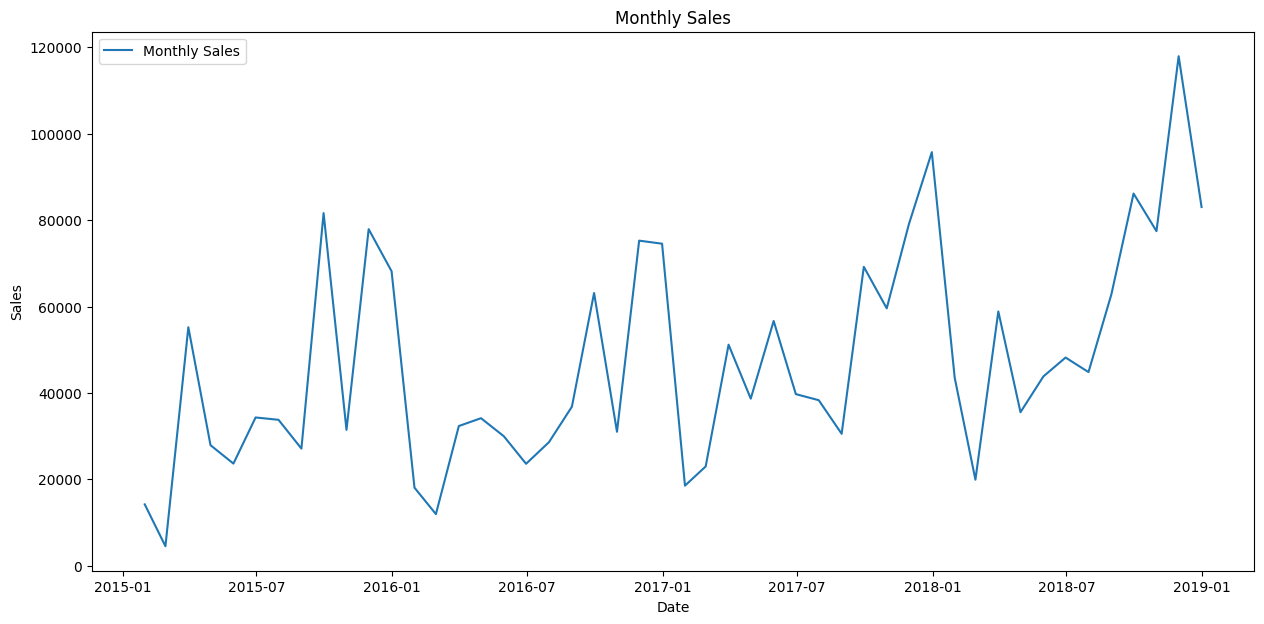

In [11]:
plt.figure(figsize=(15,7))
plt.plot(monthly_sales, label = 'Monthly Sales')
plt.title('Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

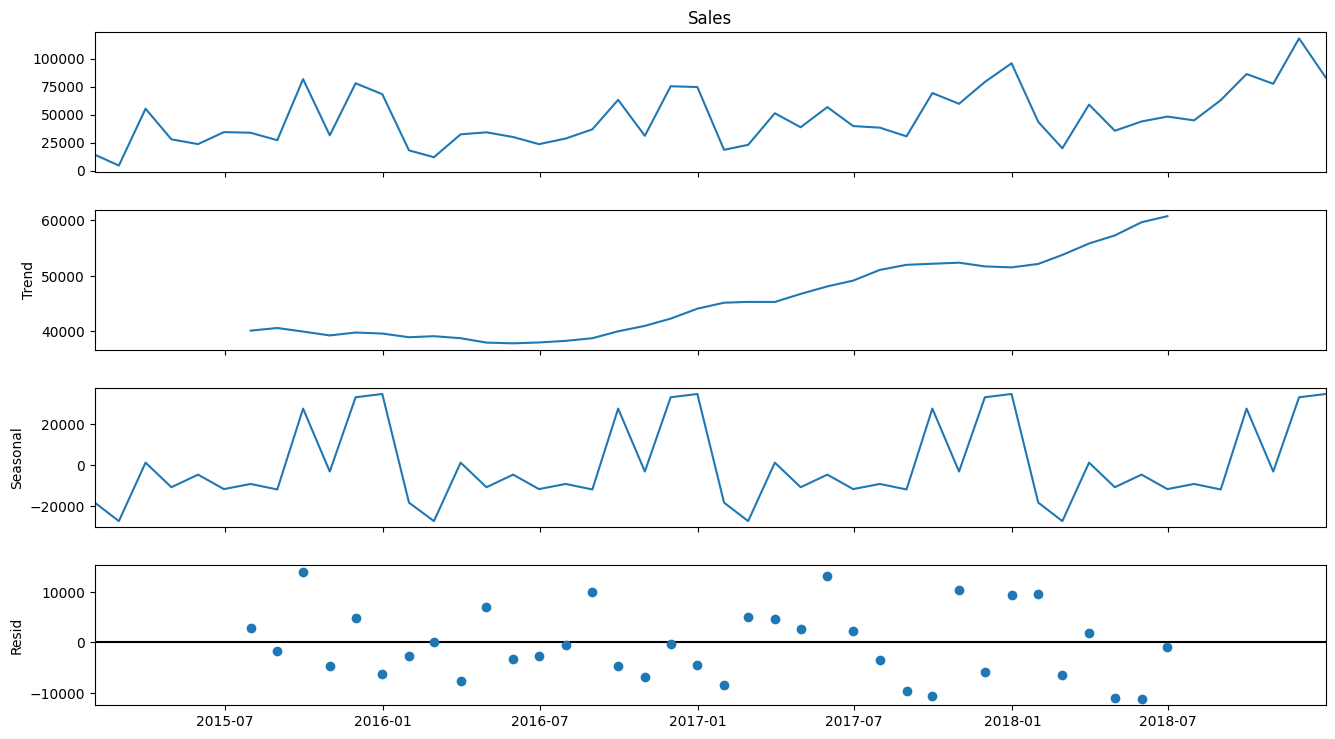

In [12]:
decomposition = seasonal_decompose(monthly_sales,model = 'additive')
fig = decomposition.plot()
fig.set_size_inches(15,8)
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

def check_stationary(timeseries):
  result = adfuller(timeseries)
  print('Augmneted Dickey-Fuller Test:')
  print('ADF Statistics', result[0])
  print('p-value', result[1])
  print('Critical Values')
  for key, value in result[4].items():
    print('\t',key, ':', value)
  return result[1]<0.05


is_stationary = check_stationary(monthly_sales)
print(f'\nTime series is stationary: {'stationary' if is_stationary else 'non_stationary'}')

Augmneted Dickey-Fuller Test:
ADF Statistics -4.416136761430769
p-value 0.00027791039276670623
Critical Values
	 1% : -3.5778480370438146
	 5% : -2.925338105429433
	 10% : -2.6007735310095064

Time series is stationary: stationary


In [14]:
auto_model = auto_arima(monthly_sales,start_p = 0, start_q = 0,max_p=5,max_q=5,m=12, seasonal = True, d = None, trace = True, error_action = 'ignore', supress_warnings = True, stepwise = True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1085.632, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1096.560, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1076.500, Time=0.13 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1077.487, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1094.708, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1089.579, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1078.250, Time=0.27 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1078.452, Time=0.16 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1080.901, Time=0.14 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1079.864, Time=0.45 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1084.035, Time=0.15 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1073.635, Time=0.15 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1087.151, Time=0.06 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1075.267, Time=0.75 sec
 ARIMA(2,1,0)(1,0,1

In [16]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_sales,order = auto_model.order, seasonal_order = auto_model.seasonal_order)

result = model.fit()

In [18]:
forcast_period = 12
forecast = result.get_forecast(steps = forcast_period)
mean_forecast = forecast.predicted_mean

In [19]:
#confidence for the model
conf_int_95 = forecast.conf_int(alpha = 0.05)
conf_int_80 = forecast.conf_int(alpha = 0.20)
conf_int_70 = forecast.conf_int(alpha = 0.30)

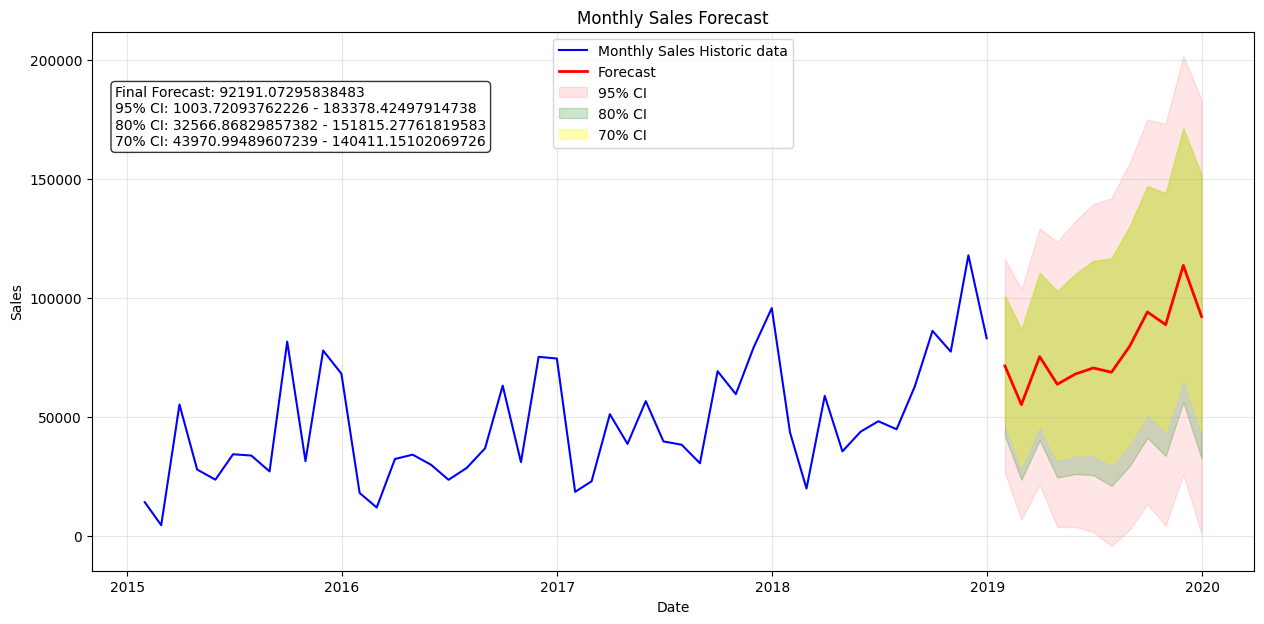

In [27]:
plt.figure(figsize = (15,7))

plt.plot(monthly_sales, label = 'Monthly Sales Historic data', color = 'blue')
plt.plot(mean_forecast, label = 'Forecast', color = 'red',linewidth = 2)

plt.fill_between(mean_forecast.index, conf_int_95.iloc[:,0], conf_int_95.iloc[:,1], color = 'red', alpha = 0.1, label = '95% CI')
plt.fill_between(mean_forecast.index, conf_int_80.iloc[:,0],conf_int_80.iloc[:,1],color = 'green',alpha = 0.2, label = '80% CI')
plt.fill_between(mean_forecast.index, conf_int_70.iloc[:,0],conf_int_80.iloc[:,1],color = 'yellow',alpha = 0.3, label = '70% CI')


plt.title('Monthly Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha = 0.3)

last_forecast = mean_forecast.iloc[-1]
range_95_lower = conf_int_95.iloc[-1,0]
range_95_upper = conf_int_95.iloc[-1,1]
range_80_lower = conf_int_80.iloc[-1,0]
range_80_upper = conf_int_80.iloc[-1,1]
range_70_lower = conf_int_70.iloc[-1,0]
range_70_upper = conf_int_70.iloc[-1,1]


info_test = f'Final Forecast: {last_forecast}\n'
info_test += f'95% CI: {range_95_lower} - {range_95_upper}\n'
info_test += f'80% CI: {range_80_lower} - {range_80_upper}\n'
info_test += f'70% CI: {range_70_lower} - {range_70_upper}'

plt.text(0.02, 0.90, info_test,
         transform = plt.gca().transAxes,
         verticalalignment = 'top',
         bbox = dict(boxstyle = 'round',
                     facecolor = 'white',
                     alpha = 0.8))

plt.show()